# Segmentation Model

In [1]:
from torch import nn
from torchvision.models.segmentation import deeplabv3_mobilenet_v3_large
from torchvision.models.segmentation import DeepLabV3_MobileNet_V3_Large_Weights

# --- 3. U-Net Completa ---
class SegmentationModel(nn.Module):
    def __init__(self, num_classes=9):
        super(SegmentationModel, self).__init__()

        # Carica modello con pesi pre-addestrati (su COCO)
        self.model = deeplabv3_mobilenet_v3_large(weights=DeepLabV3_MobileNet_V3_Large_Weights.COCO_WITH_VOC_LABELS_V1)

        # Sostituisce la testa di classificazione con il numero desiderato di classi
        self.model.classifier[-1] = nn.Conv2d(256, num_classes, kernel_size=1)

    def forward(self, x):
        return self.model(x)['out']

# Label Mapper

In [50]:
import numpy as np
from PIL import Image
import torch

class LabelMapper:
    def __init__(self):
        self.color_to_class_id_map = { # Renamed to avoid confusion
            (255, 255, 255): 0,   # Background
            (1, 88, 255): 1,      # Sky
            (156, 76, 30): 2,     # Rough Trail
            (178, 176, 153): 3,   # Smooth Trail
            (128, 255, 0): 4,     # Traversable grass
            (40, 80, 0): 5,       # High Vegetation
            (0, 160, 0): 6,       # Non Traversable Low Vegetation
            (255, 0, 128): 7,     # Puddle
            (255, 0, 0): 8        # Obstacle
        }
        # Optionally, for debugging/visualization:
        self.class_id_to_color = {v: k for k, v in self.color_to_class_id_map.items()}

    def rgb_to_class_id(self, rgb_pixel):
        # Converti il pixel in una tupla per la ricerca nel dizionario
        rgb_tuple = tuple(rgb_pixel)
        return self.color_to_class_id_map.get(rgb_tuple, 0) # Ritorna 0 (Background) se il colore non è mappato

    def class_id_to_rgb(self, class_id):
        return self.class_id_to_color.get(class_id)

    def color_to_class_id(self, labels_image: Image.Image) -> torch.Tensor:
        """
        Converts a PIL RGB image of labels to a PyTorch tensor of class IDs.
        Pixels with colors not defined in color_to_class_id_map will be mapped to 0 (Background).
        """
        labels_array = np.array(labels_image)
        height, width, _ = labels_array.shape
        class_id_map = np.zeros((height, width), dtype=np.int64)

        # Iterate through the color map and assign class IDs
        for color_tuple, class_id in self.color_to_class_id_map.items():
            # Create a boolean mask where the pixels match the current color
            match = np.all(labels_array == np.array(color_tuple).reshape(1, 1, 3), axis=2)
            class_id_map[match] = class_id

        return torch.from_numpy(class_id_map)

    def class_id_to_rgb_image(self, class_id_array: np.ndarray) -> np.ndarray:
        """
        Converts a NumPy array of class IDs to an RGB image array.
        """
        height, width = class_id_array.shape
        rgb_image_array = np.zeros((height, width, 3), dtype=np.uint8)

        for class_id, color_tuple in self.class_id_to_color.items():
            match = (class_id_array == class_id)
            rgb_image_array[match] = np.array(color_tuple)
        return rgb_image_array

# Image Processor

In [3]:
import torch

class ImageProcessor:
    def preprocess(self, image_tensor):
        return image_tensor / 255.0

    def postprocess(self, prediction_tensor_float):
        predicted_classes = torch.argmax(prediction_tensor_float, dim=1)
        predicted_classes = predicted_classes.to(torch.int64)  # usa int64, non byte
        return predicted_classes

# Rural Dataset

In [4]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
from LabelMapper import LabelMapper

class RuralDataset(Dataset):
    def __init__(self, root_dir, transform=None, augment=False):
        self.root_dir = root_dir
        self.transform = transform
        self.label_mapper = LabelMapper()
        self.augment = augment
        self.samples = []

        # Costruzione lookup table RGB -> class_id (shape: [256, 256, 256])
        self.rgb_to_id = np.full((256, 256, 256), 0, dtype=np.uint8)  # Default = background (0)
        for rgb, class_id in self.label_mapper.color_to_class_id.items():
            r, g, b = rgb
            self.rgb_to_id[r, g, b] = class_id

        # Caricamento percorsi immagini
        for folder_name in os.listdir(root_dir):
            folder_path = os.path.join(root_dir, folder_name)
            if os.path.isdir(folder_path):
                rgb_path = os.path.join(folder_path, 'rgb.jpg')
                labels_path = os.path.join(folder_path, 'labels.png')
                if os.path.exists(rgb_path) and os.path.exists(labels_path):
                    self.samples.append((rgb_path, labels_path, False))
                    if augment:
                        for _ in range(3):
                            self.samples.append((rgb_path, labels_path, True))
                else:
                    print(f"Warning: Missing rgb.jpg or labels.png in {folder_path}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        rgb_path, labels_path, apply_transform = self.samples[idx]

        # Caricamento immagini
        image = np.array(Image.open(rgb_path).convert("RGB"))
        label_rgb = np.array(Image.open(labels_path).convert("RGB"))

        # Conversione maschera RGB -> class_id (vettorializzata)
        class_id_mask = self.rgb_to_id[
            label_rgb[..., 0],
            label_rgb[..., 1],
            label_rgb[..., 2]
        ]

        # Applica le trasformazioni
        if self.transform and apply_transform:
            augmented = self.transform(image=image, mask=class_id_mask)
            image = augmented['image']
            class_id_mask = augmented['mask']
        elif self.transform:
            val_transform_subset = A.Compose([
                t for t in self.transform.transforms if isinstance(t, (A.Resize, A.Normalize, ToTensorV2))
            ], additional_targets={'mask': 'mask'})
            augmented = val_transform_subset(image=image, mask=class_id_mask)
            image = augmented['image']
            class_id_mask = augmented['mask']
        else:
            image = ToTensorV2()(image=image)['image']
            class_id_mask = torch.from_numpy(class_id_mask).long()

        return image, class_id_mask.long()


# Trainer

In [5]:
import torch
import numpy as np
from collections import Counter
from ImageProcessor import ImageProcessor
import matplotlib.pyplot as plt
from tqdm import tqdm

class Trainer:
    def __init__(self, model, train_loader, val_loader, criterion, optimizer, device, early_stopping_patience=10):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.criterion = criterion
        self.optimizer = optimizer
        self.device = device
        self.image_processor = ImageProcessor()
        self.early_stopping_patience = early_stopping_patience
        self.num_labels = 9  # classi da 0 a 8 (0 = background)

    def train_epoch(self):
        self.model.train()
        running_loss = 0.0
        with tqdm(self.train_loader, desc="Training", leave=False) as pbar:
            for batch_idx, (images, labels) in enumerate(pbar):
                images = images.to(self.device)
                labels = labels.to(self.device)
                self.optimizer.zero_grad()
                outputs = self.model(images)
                if isinstance(outputs, dict):
                    outputs = outputs["out"]
                loss = self.criterion(outputs, labels)
                loss.backward()
                self.optimizer.step()
                running_loss += loss.item()
                # Aggiorna la barra con la loss media corrente
                pbar.set_postfix({"loss": f"{loss.item():.4f}"})
        return running_loss / len(self.train_loader)

    def validate_epoch(self):
        self.model.eval()
        total_loss = 0.0
        all_predictions = []
        all_labels = []
        with torch.no_grad():
            with tqdm(self.val_loader, desc="Validation", leave=False) as pbar:
                for batch_idx, (images, labels) in enumerate(pbar):
                    images = images.to(self.device, non_blocking=True)
                    labels = labels.to(self.device, non_blocking=True)
                    outputs = self.model(images)
                    if isinstance(outputs, dict):
                        outputs = outputs["out"]
                    loss = self.criterion(outputs, labels)
                    total_loss += loss.item()
                    predictions = self.image_processor.postprocess(outputs)
                    all_predictions.append(predictions.cpu())
                    all_labels.append(labels.cpu())
                    # Aggiorna la barra con la loss media corrente
                    pbar.set_postfix({"loss": f"{loss.item():.4f}"})
        avg_loss = total_loss / len(self.val_loader) if len(self.val_loader) > 0 else 0.0
        avg_iou = 0.0
        if len(all_predictions) > 0 and len(all_labels) > 0:
            concatenated_predictions = torch.cat(all_predictions).numpy()
            concatenated_labels = torch.cat(all_labels).numpy()
            iou_scores_all_classes = self.compute_all_iou_batch(concatenated_predictions, concatenated_labels, self.num_labels)
            avg_ious_per_class = np.nan_to_num(iou_scores_all_classes)
            avg_iou = np.nanmean(iou_scores_all_classes)
        else:
            avg_ious_per_class = np.zeros(self.num_labels)
        print(f"IoU medio per classe (validation): {[f'{iou:.4f}' for iou in avg_ious_per_class]}")

        return avg_iou, avg_loss

    def run(self, num_epochs, model_save_path):
        best_val_iou = float('-inf')
        epochs_no_improve = 0
        train_losses = []
        val_losses = []

        for epoch in range(num_epochs):
            print(f"\nEpoch {epoch + 1}/{num_epochs}")

            train_loss = self.train_epoch()
            train_losses.append(train_loss)
            print(f"Train Loss: {train_loss:.4f}")

            val_iou, val_loss = self.validate_epoch()
            val_losses.append(val_loss)
            print(f"Validation mIoU: {val_iou:.4f}, Validation Loss: {val_loss:.4f}")

            if val_iou > best_val_iou:
                best_val_iou = val_iou
                torch.save(self.model.state_dict(), model_save_path)
                print(f"Nuovo modello migliore salvato in {model_save_path}")
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
                print(f"Nessun miglioramento per {epochs_no_improve} epoche.")

            if epochs_no_improve >= self.early_stopping_patience:
                print(f"Early stopping attivato dopo {epoch + 1} epoche. Miglior mIoU: {best_val_iou:.4f}")
                break

        print(f"Modello migliore (mIoU={best_val_iou:.4f}) salvato in {model_save_path}")
        self.plot_losses(train_losses, val_losses)

    @staticmethod
    def compute_class_weights(dataloader, num_classes):
        label_counts = Counter()
        total_pixels = 0
        for _, masks in dataloader:
            for mask in masks:
                pixels = mask.cpu().numpy().flatten()
                label_counts.update(pixels.tolist())
                total_pixels += len(pixels)

        weights = [0.0] * num_classes
        for i in range(num_classes):
            count = label_counts.get(i, 1e-6)
            weights[i] = total_pixels / (count * num_classes)
        return torch.tensor(weights, dtype=torch.float32)

    @staticmethod
    def get_class_distribution(dataset):
        label_counts = Counter()
        for _, mask in dataset:
            label_counts.update(mask.numpy().flatten().tolist())
        return dict(sorted(label_counts.items()))

    def compute_iou(self, mask1, mask2, label):
        intersection = np.sum((mask1 == label) & (mask2 == label))
        union = np.sum((mask1 == label) | (mask2 == label))
        if union == 0:
            return np.nan
        return intersection / union

    def compute_all_iou(self, mask1, mask2, num_labels=8):
        iou_scores = np.zeros((num_labels))
        for label in range(num_labels):
            iou = self.compute_iou(mask1, mask2, label + 1)
            iou_scores[label] = iou
        return iou_scores

    def compute_all_iou_batch(self, preds, labels, num_labels):
        # preds e labels: shape (N, H, W)
        iou_scores = np.zeros(num_labels)
        for label in range(num_labels):
            pred_mask = (preds == label)
            label_mask = (labels == label)
            intersection = np.logical_and(pred_mask, label_mask).sum()
            union = np.logical_or(pred_mask, label_mask).sum()
            if union == 0:
                iou_scores[label] = np.nan
            else:
                iou_scores[label] = intersection / union
        return iou_scores

    def plot_losses(self, train_losses, val_losses):
        plt.figure(figsize=(8, 5))
        plt.plot(train_losses, label='Training Loss')
        plt.plot(val_losses, label='Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training vs Validation Loss')
        plt.legend()
        plt.grid(True)
        plt.show()

# Evaluator

In [6]:
import numpy as np
import torch
from LabelMapper import LabelMapper

class Evaluator:
    def __init__(self, model, test_loader, device):
        self.model = model
        self.test_loader = test_loader
        self.device = device

    @staticmethod
    def calculate_iou_metric_single(prediction, ground_truth, num_classes=9):
        iou_per_class = []
        for cls in range(num_classes):
            pred_mask = (prediction == cls)
            gt_mask = (ground_truth == cls)
            intersection = torch.logical_and(pred_mask, gt_mask).sum().item()
            union = torch.logical_or(pred_mask, gt_mask).sum().item()
            if union == 0:
                iou_per_class.append(1.0)
            else:
                iou_per_class.append(intersection / union)
        return iou_per_class

    def calculate_iou_metric(self, prediction, ground_truth, num_classes=9):
        def compute_iou(mask1, mask2, label):
            intersection = np.sum((mask1 == label) & (mask2 == label))
            union = np.sum((mask1 == label) | (mask2 == label))
            if union == 0:
                return np.nan
            return intersection / union
        def compute_all_iou(mask1, mask2, num_labels=8):
            iou_scores = np.zeros((num_labels))
            for label in range(num_labels):
                iou = compute_iou(mask1, mask2, label+1)
                iou_scores[label] = iou
            return iou_scores
        if not isinstance(prediction, np.ndarray):
            prediction = prediction.cpu().numpy() if hasattr(prediction, 'cpu') else np.array(prediction)
        if not isinstance(ground_truth, np.ndarray):
            ground_truth = ground_truth.cpu().numpy() if hasattr(ground_truth, 'cpu') else np.array(ground_truth)
        return compute_all_iou(prediction, ground_truth, num_labels=num_classes-1)

    def evaluate(self):
        self.model.eval()
        all_ious = []
        with torch.no_grad():
            for images, labels in self.test_loader:
                images = images.to(self.device)
                outputs = self.model(images)
                if isinstance(outputs, dict):
                    outputs = outputs["out"]
                predictions = torch.argmax(outputs, dim=1).cpu().numpy()
                labels = labels.cpu().numpy()
                for i in range(images.shape[0]):
                    iou = self.calculate_iou_metric(predictions[i], labels[i])
                    all_ious.append(iou)
        mean_iou_per_class = np.mean(all_ious, axis=0)
        overall_mean_iou = np.mean(mean_iou_per_class)
        return overall_mean_iou, mean_iou_per_class

    def evaluate_classification_metrics(self, num_classes=9):
        from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
        self.model.eval()
        all_preds = []
        all_gts = []
        with torch.no_grad():
            for images, masks in self.test_loader:
                images = images.to(self.device)
                masks = masks.to(self.device)
                outputs = self.model(images)
                if isinstance(outputs, dict):
                    outputs = outputs["out"]
                preds = torch.argmax(outputs, dim=1)
                all_preds.append(preds.cpu().numpy().flatten())
                all_gts.append(masks.cpu().numpy().flatten())
        y_pred = np.concatenate(all_preds)
        y_true = np.concatenate(all_gts)
        metrics = {
            'accuracy': accuracy_score(y_true, y_pred),
            'precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
            'recall': recall_score(y_true, y_pred, average='macro', zero_division=0),
            'f1': f1_score(y_true, y_pred, average='macro', zero_division=0)
        }
        return metrics

    def compare_random_label_and_prediction(self, val_dataset):
        import random
        import os
        import matplotlib.pyplot as plt
        self.model.eval()
        label_mapper = LabelMapper()
        for images, labels in self.test_loader:
            idx = random.randint(0, images.shape[0] - 1)
            image = images[idx:idx + 1].to(self.device)
            label = labels[idx].cpu().numpy()
            output = self.model(image)
            if isinstance(output, dict):
                output = output["out"]
            pred = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()
            break
        if hasattr(val_dataset, 'indices'):
            original_idx = val_dataset.indices[idx]
            folder_path = val_dataset.dataset.samples[original_idx][0]
        else:
            folder_path = val_dataset.samples[idx][0]
        folder_name = os.path.basename(os.path.dirname(folder_path))
        def mask_to_rgb(mask):
            h, w = mask.shape
            rgb = np.zeros((h, w, 3), dtype=np.uint8)
            for cls in np.unique(mask):
                rgb[mask == cls] = label_mapper.class_id_to_rgb(cls)
            return rgb
        label_rgb = mask_to_rgb(label)
        pred_rgb = mask_to_rgb(pred)
        plt.figure(figsize=(10, 5))
        plt.suptitle(f"Folder origine: {folder_name}")
        plt.subplot(1, 2, 1)
        plt.title("Label reale")
        plt.imshow(label_rgb.astype(np.uint8))
        plt.axis('off')
        plt.subplot(1, 2, 2)
        plt.title("Predizione")
        plt.imshow(pred_rgb.astype(np.uint8))
        plt.axis('off')
        plt.show()

    def compute_iou(self, mask1, mask2, label):
        intersection = np.sum((mask1 == label) & (mask2 == label))
        union = np.sum((mask1 == label) | (mask2 == label))
        if union == 0:
            return np.nan
        return intersection / union

    def compute_all_iou(self, mask1, mask2, num_labels=8):
        iou_scores = np.zeros((num_labels))
        for label in range(num_labels):
            iou = self.compute_iou(mask1, mask2, label + 1)
            iou_scores[label] = iou
        return iou_scores

    def predict_from_folder(self, folder_number, data_root='train'):
        import os
        import matplotlib.pyplot as plt
        from PIL import Image
        from torchvision import transforms
        folder_name = f"{int(folder_number):04d}"
        folder_path = os.path.join(data_root, folder_name)
        rgb_path = os.path.join(folder_path, 'rgb.jpg')
        label_path = os.path.join(folder_path, 'labels.png')
        if not (os.path.exists(rgb_path) and os.path.exists(label_path)):
            print(f"Immagini non trovate in {folder_path}")
            return
        image = Image.open(rgb_path).convert("RGB")
        label_image = Image.open(label_path).convert("RGB")
        label_np = np.array(label_image)
        label_mapper = LabelMapper()
        class_id_mask = np.zeros((label_np.shape[0], label_np.shape[1]), dtype=np.uint8)
        for r in range(label_np.shape[0]):
            for c in range(label_np.shape[1]):
                pixel_rgb = tuple(label_np[r, c])
                class_id_mask[r, c] = label_mapper.rgb_to_class_id(pixel_rgb)
        class_id_mask = np.array(Image.fromarray(class_id_mask).resize((512, 272), resample=Image.NEAREST))
        val_transform = transforms.Compose([
            transforms.Resize((272, 512)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
        image_tensor = val_transform(image).unsqueeze(0).to(self.device)
        self.model.eval()
        with torch.no_grad():
            output = self.model(image_tensor)
            if isinstance(output, dict):
                output = output["out"]
            pred_mask = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

        def id_to_rgb_mask(id_mask, id_to_color_map):
            h, w = id_mask.shape
            rgb_mask = np.zeros((h, w, 3), dtype=np.uint8)
            for class_id, color_rgb in id_to_color_map.items():
                rgb_mask[id_mask == class_id] = color_rgb
            return rgb_mask

        id_to_color = label_mapper.class_id_to_color
        true_label_rgb = id_to_rgb_mask(class_id_mask, id_to_color)
        pred_label_rgb = id_to_rgb_mask(pred_mask, id_to_color)
        plt.figure(figsize=(18, 6))
        plt.subplot(1, 3, 1)
        plt.title('Immagine RGB')
        plt.imshow(image)
        plt.axis('off')
        plt.subplot(1, 3, 2)
        plt.title('Label reale')
        plt.imshow(true_label_rgb)
        plt.axis('off')
        plt.subplot(1, 3, 3)
        plt.title('Label predetta')
        plt.imshow(pred_label_rgb)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        correct = (pred_mask == class_id_mask).sum()
        total = class_id_mask.size
        print(f"Pixel classificati correttamente: {correct} / {total} ({correct / total:.2%})")
        iou_scores = self.compute_all_iou(pred_mask, class_id_mask, num_labels=8)
        mean_iou = np.nanmean(iou_scores)
        print(f"IoU medio sull'immagine: {mean_iou:.4f}")
        print(f"IoU per classe: {iou_scores}")

    def predict_from_all_folders(self, data_root='test'):
        import os
        import numpy as np
        from PIL import Image
        from torchvision import transforms
        import torch
        import matplotlib.pyplot as plt
        label_mapper = LabelMapper()
        all_iou_scores = []
        all_accuracies = []
        folders = [f for f in os.listdir(data_root) if os.path.isdir(os.path.join(data_root, f))]
        folders.sort()
        for folder_name in folders:
            folder_path = os.path.join(data_root, folder_name)
            rgb_path = os.path.join(folder_path, 'rgb.jpg')
            label_path = os.path.join(folder_path, 'labels.png')
            if not (os.path.exists(rgb_path) and os.path.exists(label_path)):
                print(f"Immagini non trovate in {folder_path}")
                continue
            image = Image.open(rgb_path).convert("RGB")
            label_image = Image.open(label_path).convert("RGB")
            label_np = np.array(label_image)
            class_id_mask = np.zeros((label_np.shape[0], label_np.shape[1]), dtype=np.uint8)
            for r in range(label_np.shape[0]):
                for c in range(label_np.shape[1]):
                    pixel_rgb = tuple(label_np[r, c])
                    class_id_mask[r, c] = label_mapper.rgb_to_class_id(pixel_rgb)
            class_id_mask = np.array(Image.fromarray(class_id_mask).resize((512, 272), resample=Image.NEAREST))
            val_transform = transforms.Compose([
                transforms.Resize((272, 512)),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ])
            image_tensor = val_transform(image).unsqueeze(0).to(self.device)
            self.model.eval()
            with torch.no_grad():
                output = self.model(image_tensor)
                if isinstance(output, dict):
                    output = output["out"]
                pred_mask = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()
            correct = (pred_mask == class_id_mask).sum()
            total = class_id_mask.size
            accuracy = correct / total
            iou_scores = self.compute_all_iou(pred_mask, class_id_mask, num_labels=8)
            mean_iou = np.nanmean(iou_scores)
            all_iou_scores.append(iou_scores)
            all_accuracies.append(accuracy)
            print(f"Cartella: {folder_name}")
            print(f"  Pixel classificati correttamente: {correct} / {total} ({accuracy:.2%})")
            print(f"  IoU medio sull'immagine: {mean_iou:.4f}")
            print(f"  IoU per classe: {iou_scores}")

            # --- PLOT ---
            def id_to_rgb_mask(id_mask, id_to_color_map):
                h, w = id_mask.shape
                rgb_mask = np.zeros((h, w, 3), dtype=np.uint8)
                for class_id, color_rgb in id_to_color_map.items():
                    rgb_mask[id_mask == class_id] = color_rgb
                return rgb_mask

            id_to_color = label_mapper.class_id_to_color
            true_label_rgb = id_to_rgb_mask(class_id_mask, id_to_color)
            pred_label_rgb = id_to_rgb_mask(pred_mask, id_to_color)
            plt.figure(figsize=(18, 6))
            plt.suptitle(f"Risultati cartella: {folder_name}")
            plt.subplot(1, 3, 1)
            plt.title('Immagine RGB')
            plt.imshow(image)
            plt.axis('off')
            plt.subplot(1, 3, 2)
            plt.title('Label reale')
            plt.imshow(true_label_rgb)
            plt.axis('off')
            plt.subplot(1, 3, 3)
            plt.title('Label predetta')
            plt.imshow(pred_label_rgb)
            plt.axis('off')
            plt.tight_layout()
            plt.show()
        if all_iou_scores:
            all_iou_scores = np.array(all_iou_scores)
            mean_iou_per_class = np.nanmean(all_iou_scores, axis=0)
            mean_iou_total = np.nanmean(all_iou_scores)
            mean_accuracy = np.mean(all_accuracies)
            print("\n--- Risultati medi su tutte le cartelle ---")
            print(f"Accuratezza media: {mean_accuracy:.2%}")
            print(f"IoU medio totale: {mean_iou_total:.4f}")
            print(f"IoU medio per classe: {mean_iou_per_class}")
        else:
            print("Nessuna cartella valida trovata.")


# Main

In [7]:
torch.cuda.empty_cache()
from torch.nn import CrossEntropyLoss
from segmentation_models_pytorch.losses import DiceLoss, FocalLoss
from torch.utils.data import DataLoader

DATA_ROOT = 'train'
BATCH_SIZE = 16
LEARNING_RATE = 0.00001
NUM_EPOCHS = 100
NUM_CLASSES = 9
MODEL_SAVE_PATH = 'saved_model.pth'
LRSAPP_MOBILENETV3_MODEL = 'lrsapp_mobilenetv3_model.pth'
UNET_RESNET34_MODEL = 'unet_resnet34_model.pth'

if torch.cuda.is_available():
    device = torch.device('cuda')  # Configura per utilizzare la GPU
    print(f"Utilizzo GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device('cpu')  # Fallback alla CPU
    print("CUDA non disponibile, utilizzo CPU")

Utilizzo GPU: NVIDIA GeForce RTX 5070 Ti


In [8]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Define Albumentations transformations
train_albumentations_transform = A.Compose([
    #A.RandomResizedCrop(size=(512, 512), scale=(0.8, 1.0), ratio=(0.9, 1.1)),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    #A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
    A.Rotate(limit=10, p=0.5),
    #A.Affine(translate_percent=(0.05, 0.05), scale=(0.95, 1.05), shear=5, p=0.5),
    #A.Perspective(scale=(0.01, 0.1), p=0.3),
    #A.GaussianBlur(blur_limit=5, sigma_limit=(0.1, 2.0), p=0.5),
    A.Resize(height=272, width=512),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
], additional_targets={'mask': 'mask'})

val_albumentations_transform = A.Compose([
    A.Resize(height=272, width=512),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
], additional_targets={'mask': 'mask'})

In [9]:
from torch.utils.data import random_split, Subset, DataLoader

# Dataset completo con augmentazione (ogni immagine originale ha 2 campioni: originale + augmentata)
full_train_augmented_dataset = RuralDataset(root_dir=DATA_ROOT, transform=train_albumentations_transform, augment=True)

# Dataset originale senza augmentazioni (solo per calcolare split)
original_dataset = RuralDataset(root_dir=DATA_ROOT, transform=None, augment=False)
train_size = int(0.8 * len(original_dataset))  # es. 744
val_size = len(original_dataset) - train_size  # es. 187

# Divido gli indici del dataset originale in train/val
train_indices, val_indices = random_split(range(len(original_dataset)), [train_size, val_size])

# Ora per ogni indice i dell'originale prendo due campioni nell'augmented dataset: i*2 e i*2+1
expanded_train_indices = []
for idx in train_indices:
    base = idx * 2
    expanded_train_indices.extend([base, base + 1])

train_dataset = Subset(full_train_augmented_dataset, expanded_train_indices)

val_dataset_full = RuralDataset(root_dir=DATA_ROOT, transform=val_albumentations_transform, augment=False)
val_dataset = Subset(val_dataset_full, val_indices)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, num_workers=0, shuffle=True, pin_memory=True)

val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, num_workers=0, shuffle=False, pin_memory=True)

print(f"Training on {len(train_loader.dataset)} samples, validating on {len(val_loader.dataset)} samples.")


Training on 1488 samples, validating on 187 samples.


In [10]:
#model = SegmentationModel(NUM_CLASSES)
#from torchvision.models.segmentation import *

#model = lraspp_mobilenet_v3_large(num_classes=NUM_CLASSES)
model = SegmentationModel()

model.to(device)
print("Model architecture:")
print(model)

Model architecture:
SegmentationModel(
  (model): DeepLabV3(
    (backbone): IntermediateLayerGetter(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          )
        )
      )
      (2): InvertedResidual(
        (block): Sequential(

In [11]:
#weights = Trainer.compute_class_weights(train_loader, num_classes=NUM_CLASSES)
#weights = [1.6943,  0.9851,  0.6781,  0.6303,  0.9297,  0.3616,  2.3487, 80.9508, 18.3638]

#cross_entropy = CrossEntropyLoss(weight=torch.tensor(weights).to(device))
#cross_entropy = CrossEntropyLoss(weight=weights.to(device))
focal_loss = FocalLoss(mode='multiclass', gamma=2.0)
dice_loss = DiceLoss(mode='multiclass')

def combined_loss(pred, target):
    return 0.3*(focal_loss(pred, target)) + 0.7*(dice_loss(pred, target))

criterion = combined_loss
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


Starting training...

Epoch 1/100


Train Loss: 1.0025


IoU medio per classe (validation): ['0.1022', '0.1824', '0.2475', '0.3947', '0.1407', '0.2458', '0.0001', '0.0208', '0.0001']
Validation mIoU: 0.1483, Validation Loss: 0.9485
Nuovo modello migliore salvato in saved_model.pth

Epoch 2/100


Train Loss: 0.8594


IoU medio per classe (validation): ['0.2141', '0.4967', '0.3220', '0.4639', '0.3239', '0.6600', '0.0391', '0.0445', '0.0008']
Validation mIoU: 0.2850, Validation Loss: 0.8057
Nuovo modello migliore salvato in saved_model.pth

Epoch 3/100


...

IoU medio per classe (validation): ['0.5496', '0.8683', '0.6257', '0.6654', '0.5481', '0.8355', '0.4471', '0.7557', '0.7338']
Validation mIoU: 0.6699, Validation Loss: 0.3734
Nessun miglioramento per 8 epoche.

Epoch 83/100


Train Loss: 0.1581


IoU medio per classe (validation): ['0.5536', '0.8712', '0.6140', '0.6616', '0.5448', '0.8359', '0.4473', '0.7010', '0.7712']
Validation mIoU: 0.6667, Validation Loss: 0.3779
Nessun miglioramento per 9 epoche.

Epoch 84/100


Train Loss: 0.1618


IoU medio per classe (validation): ['0.5584', '0.8713', '0.6111', '0.6616', '0.5419', '0.8339', '0.4433', '0.7294', '0.7291']
Validation mIoU: 0.6645, Validation Loss: 0.3778
Nessun miglioramento per 10 epoche.
Early stopping attivato dopo 84 epoche. Miglior mIoU: 0.6713
Modello migliore (mIoU=0.6713) salvato in saved_model.pth


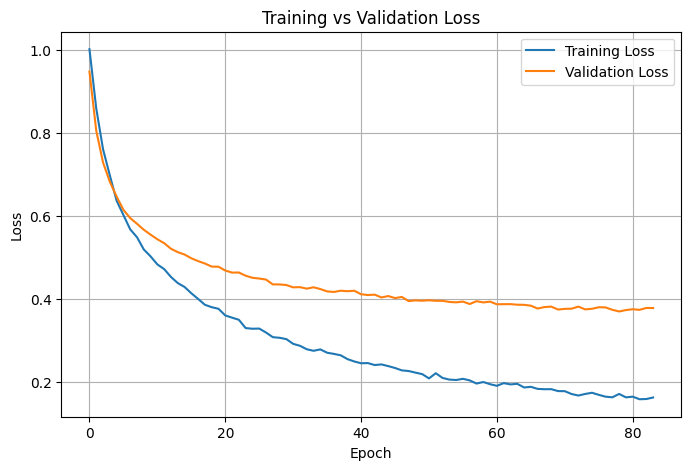

TypeError: cannot unpack non-iterable NoneType object

In [12]:
trainer = Trainer(model, train_loader, val_loader, criterion, optimizer, device)
print("\nStarting training...")
trainer.run(num_epochs=NUM_EPOCHS, model_save_path=MODEL_SAVE_PATH)
print("Training finished.")

In [16]:
model.load_state_dict(torch.load(MODEL_SAVE_PATH))
model.to(device)
# model.load_state_dict(torch.load(UNET_RESNET34_MODEL))
evaluator = Evaluator(model, val_loader, device)
metrics = evaluator.evaluate_classification_metrics()

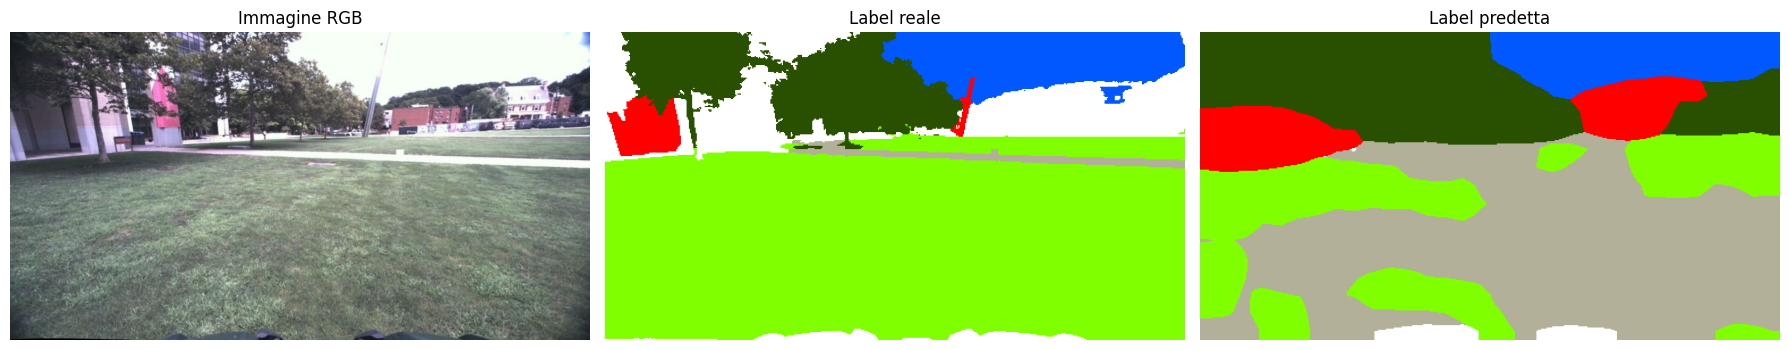

Pixel classificati correttamente: 59248 / 139264 (42.54%)
IoU medio sull'immagine: 0.3934
IoU per classe: [0.87735397        nan 0.01930482 0.3115005  0.5595399         nan
        nan 0.19925611]


In [24]:
evaluator.predict_from_folder(folder_number = 6, data_root = 'prova')

In [23]:
print(metrics.get('accuracy', 'N/A'))
print(metrics.get('f1_score', 'N/A'))
print(metrics.get('precision', 'N/A'))
print(metrics.get('recall', 'N/A'))

0.8259389468730339
N/A
0.787765251304953
0.8114807868874389


In [ ]:
evaluator.predict_from_all_folders(data_root = 'test')

In [56]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm import tqdm
from torchvision import transforms

from ImageProcessor import ImageProcessor
processor = ImageProcessor()
label_mapper = LabelMapper()

def predict(model, image_numpy):
    import torch
    from PIL import Image
    import numpy as np
    from torchvision import transforms
    model.eval()
    with torch.no_grad():
        image_pil = Image.fromarray(image_numpy).convert("RGB")
        val_transform = transforms.Compose([
            transforms.Resize((272, 512)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
        image_tensor = val_transform(image_pil).unsqueeze(0).to(model.device if hasattr(model, 'device') else 'cpu')
        output = model(image_tensor)
        if isinstance(output, dict):
            output = output["out"]
        pred_mask = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()
        pred_mask_resized = np.array(Image.fromarray(pred_mask.astype(np.uint8)).resize((1024, 544), resample=Image.NEAREST))
    return pred_mask_resized


import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# Metrics
def compute_iou(mask1, mask2, label):
  intersection = np.sum((mask1 == label) & (mask2 == label))
  union = np.sum((mask1 == label) | (mask2 == label))
  if union == 0:
    return np.nan
  return intersection / union
def compute_all_iou(mask1, mask2, num_labels=8):
  iou_scores = np.zeros((num_labels))
  for label in range(num_labels):
    iou = compute_iou(mask1, mask2, label+1) # we skip the background label
    iou_scores[label] = iou
  return iou_scores


# Run YOUR LOAD_MODEL FUNCTION
model = SegmentationModel(NUM_CLASSES) # Create an instance of your model class
model.load_state_dict(torch.load(MODEL_SAVE_PATH))

# Main loop
test_dir = "test"  # we will change this path with that of the private test set directory
samples = os.listdir(test_dir)
IOUs = np.zeros((len(samples), 8))
verbose = False

for i, subdir in tqdm(enumerate(samples), desc="Processing samples"):
    subdir_path = os.path.join(test_dir, subdir)

    if os.path.isdir(subdir_path):
        # Get the data paths
        rgb_path = os.path.join(subdir_path, 'rgb.jpg')
        labels_path = os.path.join(subdir_path, 'labels.png')

        if os.path.exists(rgb_path) and os.path.exists(labels_path):
            if verbose:
                print(f"Processing subdirectory: {subdir}")

            try:  # ATTENTION: any error occurring in this try-catch means that the corresponding IOUs are evaluated as ZERO

                # Open images
                rgb_image = Image.open(rgb_path)
                rgb_array = np.asarray(rgb_image).copy()
                labels_image = Image.open(labels_path).convert("RGB")
                labels_array = label_mapper.color_to_class_id(labels_image).numpy()

                if verbose:
                    print(f"  Loaded {rgb_path} and {labels_path}")

                # Run YOUR PREDICT FUNCTION
                predicted_labels_array = predict(model, rgb_array)

                # Evaluate the IOU metric
                IOUs[i,:] = compute_all_iou(labels_array, predicted_labels_array)

                if verbose:
                    labels_vals = np.unique(np.asarray(labels_image))
                    print(f"  Unique labels values: {labels_vals}")
                    predicted_labels_vals = np.unique(np.asarray(predicted_labels_array))
                    print(f"  Unique predicted labels values: {predicted_labels_vals}")

                    plt.subplot(1, 3, 1)
                    plt.imshow(rgb_image)
                    plt.subplot(1, 3, 2)
                    plt.imshow(labels_image)
                    plt.subplot(1, 3, 3)
                    plt.imshow(predicted_labels_array)
                    plt.show()

                rgb_image.close()
                labels_image.close()

            except FileNotFoundError:
                print(f"  Error: Could not find image files in {subdir_path}")
            except Exception as e:
                print(f"  Error processing images in {subdir_path}: {e}")
        else:
            print(f"  Skipping subdirectory {subdir}: rgb.jpg or labels.png not found.")

score = np.nanmean(IOUs)
print(f"\nFinal competition score: {score}")

Processing samples: 144it [00:19,  7.31it/s]


Final competition score: 0.45052465939628367
